# Chapter 2 Computer Lab
## Euclidean Space $\mathbb R^n$: Coordinates, Distance, Projections, Balls, Spheres, and Data Geometry

This Python lab accompanies Chapter 2 of the multivariable calculus text.  The chapter moves from the real line to $\mathbb R^2$, $\mathbb R^3$, and $\mathbb R^n$, emphasizing the geometry and computation of points, vectors, distances, coordinate-plane projections, spheres, balls, and regions defined by equations or inequalities.

### Learning goals

By the end of this lab, you should be able to:

1. represent points and vectors in Python using NumPy arrays;
2. compute displacement vectors and Euclidean distances in $\mathbb R^n$;
3. visualize points, coordinate projections, lines, planes, spheres, balls, and cylinders;
4. recognize how an equation changes meaning when the ambient space changes;
5. use distance to solve geometric and data-analysis problems;
6. explore how Euclidean distance behaves in high dimensions.

### How to use this notebook

Run the cells in order.  When you see a **Task**, first try to complete the student workspace without looking ahead.  Reference solutions and checks are included so that the notebook can also be used for independent study.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 3D plotting support
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Cleaner numerical output
np.set_printoptions(precision=4, suppress=True)

print("Packages loaded.")

Packages loaded.


## 1. Points, vectors, and displacement

A point records a location.  A vector records displacement, direction, or magnitude.  In computation, both are often stored as arrays.

If

$$
A=(a_1,a_2,\ldots,a_n), \qquad B=(b_1,b_2,\ldots,b_n),
$$

then the displacement from $A$ to $B$ is

$$
\overrightarrow{AB}=B-A=(b_1-a_1,b_2-a_2,\ldots,b_n-a_n).
$$

This is the first computational idea of Euclidean geometry: subtract points to obtain a vector.

A = [1 1]
B = [4 3]
Displacement B - A = [3 2]


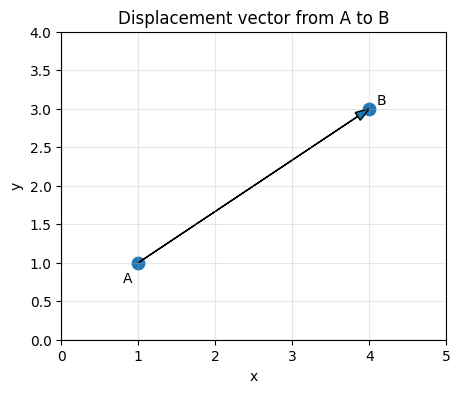

In [2]:
A = np.array([1, 1])
B = np.array([4, 3])
v = B - A

print("A =", A)
print("B =", B)
print("Displacement B - A =", v)

plt.figure(figsize=(6, 4))
plt.scatter([A[0], B[0]], [A[1], B[1]], s=80)
plt.text(A[0] - 0.2, A[1] - 0.25, "A")
plt.text(B[0] + 0.10, B[1] + 0.05, "B")
plt.arrow(A[0], A[1], v[0], v[1], head_width=0.12, length_includes_head=True)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlim(0, 5)
plt.ylim(0, 4)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Displacement vector from A to B")
plt.grid(True, alpha=0.3)
plt.show()

### Task 1.1

Let

$$
A=(-2,3,1), \qquad B=(0,4,0).
$$

Compute the displacement vector $\overrightarrow{AB}=B-A$.

In [3]:
# Student workspace for Task 1.1
A = np.array([-2, 3, 1])
B = np.array([0, 4, 0])

# Fill in the displacement vector.
displacement = B - A

print("B - A =", displacement)

B - A = [ 2  1 -1]


**Reference solution.**

$$
B-A=(0-(-2),4-3,0-1)=(2,1,-1).
$$

In [4]:
assert np.allclose(displacement, np.array([2, 1, -1]))
print("Task 1.1 check passed.")

Task 1.1 check passed.


## 2. Euclidean norm and Euclidean distance

The Euclidean norm of a vector

$$
v=(v_1,\ldots,v_n)
$$

is

$$
\|v\|=\sqrt{v_1^2+\cdots+v_n^2}.
$$

The distance between two points $A$ and $B$ is the norm of the displacement vector:

$$
d(A,B)=\|B-A\|=\sqrt{(b_1-a_1)^2+\cdots+(b_n-a_n)^2}.
$$

In [5]:
def norm(v):
    """Return the Euclidean norm of a vector v."""
    v = np.asarray(v, dtype=float)
    return np.sqrt(np.sum(v**2))


def distance(a, b):
    """Return the Euclidean distance between points a and b."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return norm(b - a)

P = np.array([1, 2, 3])
Q = np.array([3, 4, 2])

print("P =", P)
print("Q =", Q)
print("Q - P =", Q - P)
print("dist(P,Q) =", distance(P, Q))
print("np.linalg.norm(P-Q) =", np.linalg.norm(P - Q))

P = [1 2 3]
Q = [3 4 2]
Q - P = [ 2  2 -1]
dist(P,Q) = 3.0
np.linalg.norm(P-Q) = 3.0


### Task 2.1

Find the distance between

$$
a=(2,-1,0,4), \qquad b=(-1,3,5,2)
$$

in $\mathbb R^4$.

In [6]:
# Student workspace for Task 2.1
a = np.array([2, -1, 0, 4])
b = np.array([-1, 3, 5, 2])

# Fill in these quantities.
displacement_ab = b - a
distance_ab = distance(a, b)

print("b - a =", displacement_ab)
print("dist(a,b) =", distance_ab)

b - a = [-3  4  5 -2]
dist(a,b) = 7.3484692283495345


**Reference solution.**

$$
b-a=(-3,4,5,-2),
$$

so

$$
d(a,b)=\sqrt{(-3)^2+4^2+5^2+(-2)^2}=\sqrt{54}=3\sqrt 6.
$$

In [7]:
assert np.allclose(displacement_ab, np.array([-3, 4, 5, -2]))
assert np.allclose(distance_ab, np.sqrt(54))
print("Task 2.1 check passed.")

Task 2.1 check passed.


### Task 2.2: Write your own distance function

Complete the function below without using `np.linalg.norm`.  Then test it on the examples above.

In [8]:
# Student workspace for Task 2.2
def my_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.sqrt(np.sum((b - a)**2))

print(my_distance([1, 2, 3], [3, 4, 2]))
print(my_distance([2, -1, 0, 4], [-1, 3, 5, 2]))

3.0
7.3484692283495345


In [9]:
assert np.allclose(my_distance([1, 2, 3], [3, 4, 2]), 3)
assert np.allclose(my_distance([2, -1, 0, 4], [-1, 3, 5, 2]), np.sqrt(54))
print("Task 2.2 check passed.")

Task 2.2 check passed.


## 3. Coordinate planes and projections in $\mathbb R^3$

The coordinate planes in $\mathbb R^3$ are

$$
xy\text{-plane}: z=0, \qquad yz\text{-plane}: x=0, \qquad xz\text{-plane}: y=0.
$$

For a point $P=(a,b,c)$,

$$
P_{xy}=(a,b,0), \qquad P_{yz}=(0,b,c), \qquad P_{xz}=(a,0,c).
$$

Projection onto a coordinate plane means setting the missing coordinate equal to zero.

In [10]:
def project_xy(P):
    P = np.asarray(P, dtype=float)
    return np.array([P[0], P[1], 0.0])


def project_yz(P):
    P = np.asarray(P, dtype=float)
    return np.array([0.0, P[1], P[2]])


def project_xz(P):
    P = np.asarray(P, dtype=float)
    return np.array([P[0], 0.0, P[2]])

P = np.array([2, 3, 4])
projections = {
    "P": P,
    "xy projection": project_xy(P),
    "yz projection": project_yz(P),
    "xz projection": project_xz(P),
}

for name, point in projections.items():
    print(f"{name:14s}: {point}")

P             : [2 3 4]
xy projection : [2. 3. 0.]
yz projection : [0. 3. 4.]
xz projection : [2. 0. 4.]


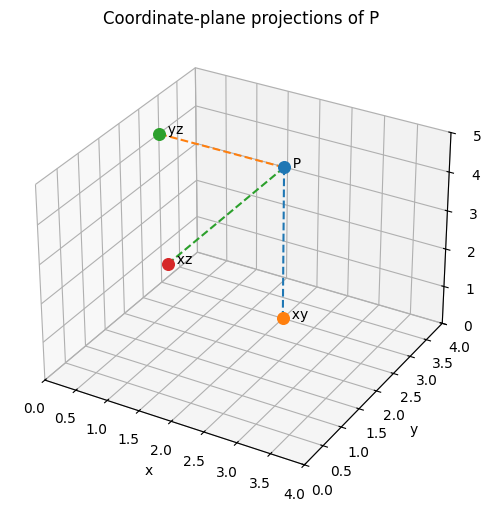

In [11]:
P = np.array([2, 3, 4])
P_xy = project_xy(P)
P_yz = project_yz(P)
P_xz = project_xz(P)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

points = [P, P_xy, P_yz, P_xz]
labels = ["P", "xy", "yz", "xz"]

for Q, label in zip(points, labels):
    ax.scatter(Q[0], Q[1], Q[2], s=70)
    ax.text(Q[0], Q[1], Q[2], "  " + label)

for Q in [P_xy, P_yz, P_xz]:
    ax.plot([P[0], Q[0]], [P[1], Q[1]], [P[2], Q[2]], linestyle="--")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_zlim(0, 5)
ax.set_title("Coordinate-plane projections of P")
plt.show()

### Task 3.1

Let $P=(5,-2,7)$.  Find its projections onto the $xy$-, $yz$-, and $xz$-planes.

In [12]:
# Student workspace for Task 3.1
P = np.array([5, -2, 7])

P_xy = project_xy(P)
P_yz = project_yz(P)
P_xz = project_xz(P)

print("P_xy =", P_xy)
print("P_yz =", P_yz)
print("P_xz =", P_xz)

P_xy = [ 5. -2.  0.]
P_yz = [ 0. -2.  7.]
P_xz = [5. 0. 7.]


**Reference solution.**

$$
P_{xy}=(5,-2,0), \qquad P_{yz}=(0,-2,7), \qquad P_{xz}=(5,0,7).
$$

In [13]:
assert np.allclose(P_xy, [5, -2, 0])
assert np.allclose(P_yz, [0, -2, 7])
assert np.allclose(P_xz, [5, 0, 7])
print("Task 3.1 check passed.")

Task 3.1 check passed.


## 4. Equations depend on the ambient space

An equation does not describe an object until we know the ambient space.

For example:

- in $\mathbb R^2$, $y=2$ is a line;
- in $\mathbb R^3$, $y=2$ is a plane parallel to the $xz$-plane.

Likewise:

- in $\mathbb R^2$, $x^2+y^2=4$ is a circle;
- in $\mathbb R^3$, $x^2+y^2=4$ is a cylinder, because $z$ is free.

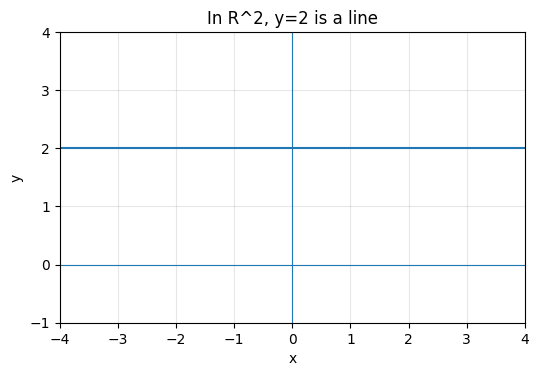

In [14]:
# y = 2 in R^2
x = np.linspace(-4, 4, 200)
y = 2 * np.ones_like(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlim(-4, 4)
plt.ylim(-1, 4)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x")
plt.ylabel("y")
plt.title("In R^2, y=2 is a line")
plt.grid(True, alpha=0.3)
plt.show()

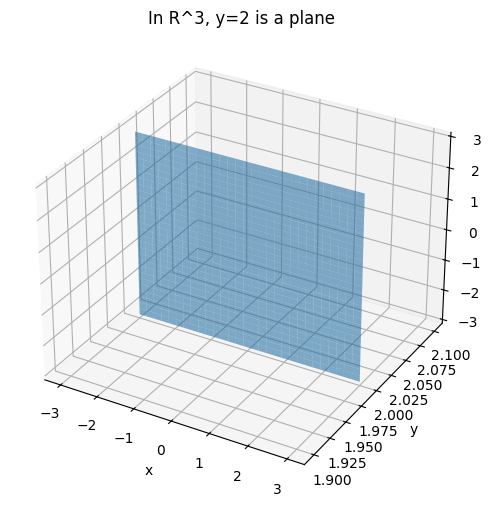

In [15]:
# y = 2 in R^3
x = np.linspace(-3, 3, 30)
z = np.linspace(-3, 3, 30)
X, Z = np.meshgrid(x, z)
Y = 2 * np.ones_like(X)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("In R^3, y=2 is a plane")
plt.show()

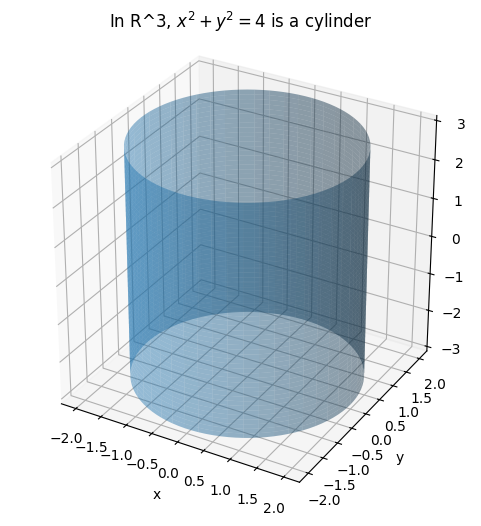

In [16]:
# x^2 + y^2 = 4 in R^3 is a cylinder.
theta = np.linspace(0, 2*np.pi, 100)
z_vals = np.linspace(-3, 3, 50)
Theta, Z = np.meshgrid(theta, z_vals)
X = 2 * np.cos(Theta)
Y = 2 * np.sin(Theta)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.45, linewidth=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1, 1, 1])
ax.set_title(r"In R^3, $x^2+y^2=4$ is a cylinder")
plt.show()

### Task 4.1

Describe the object $x^2+z^2=1$ in $\mathbb R^3$.

Then use the code cell below to plot it.

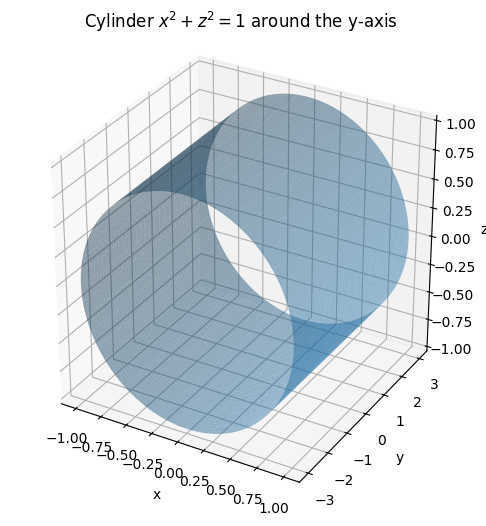

In [17]:
# Student workspace for Task 4.1
# x^2 + z^2 = 1 is a cylinder around the y-axis.
theta = np.linspace(0, 2*np.pi, 100)
y_vals = np.linspace(-3, 3, 50)
Theta, Y = np.meshgrid(theta, y_vals)
X = np.cos(Theta)
Z = np.sin(Theta)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.45, linewidth=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1, 1, 1])
ax.set_title(r"Cylinder $x^2+z^2=1$ around the y-axis")
plt.show()

**Reference solution.**  The variable $y$ is free, so $x^2+z^2=1$ describes a circular cylinder of radius $1$ whose axis is the $y$-axis.

## 5. Spheres and balls

In $\mathbb R^3$, the sphere with center $C=(h,k,\ell)$ and radius $r$ has equation

$$
(x-h)^2+(y-k)^2+(z-\ell)^2=r^2.
$$

The closed ball is the solid region

$$
(x-h)^2+(y-k)^2+(z-\ell)^2\le r^2.
$$

The open ball uses $<$ instead of $\le$.

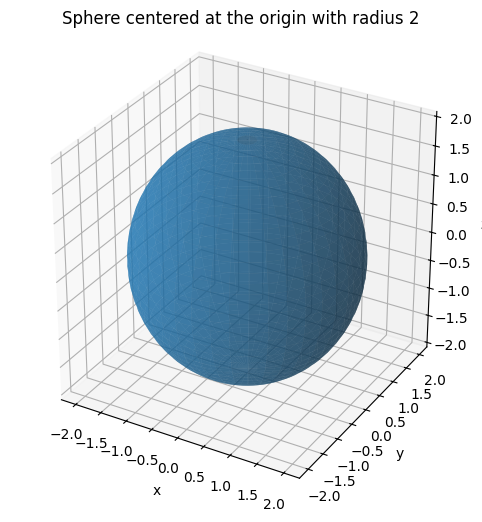

In [18]:
def sphere_points(center=(0, 0, 0), radius=1, n_u=80, n_v=40):
    """Return mesh arrays X, Y, Z for a sphere."""
    center = np.asarray(center, dtype=float)
    u = np.linspace(0, 2*np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)
    X = center[0] + radius * np.outer(np.cos(u), np.sin(v))
    Y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
    Z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))
    return X, Y, Z

X, Y, Z = sphere_points(center=(0, 0, 0), radius=2)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.6, linewidth=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1, 1, 1])
ax.set_title("Sphere centered at the origin with radius 2")
plt.show()

### Task 5.1

Find the equation of the sphere with center $(2,-5,1)$ and radius $2$.  Then plot it.

Sphere equation:
(x - 2)^2 + (y + 5)^2 + (z - 1)^2 = 4


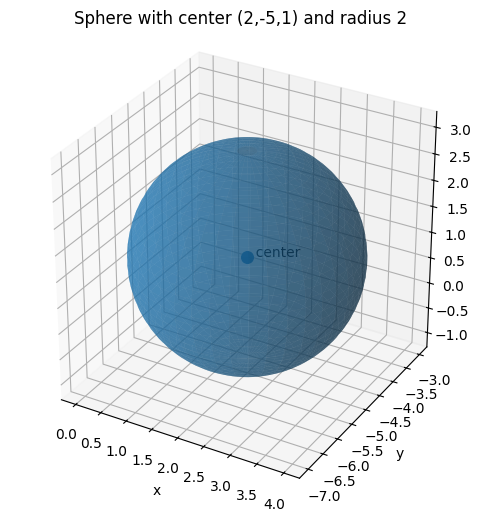

In [19]:
# Student workspace for Task 5.1
center = np.array([2, -5, 1])
radius = 2

print("Sphere equation:")
print("(x - 2)^2 + (y + 5)^2 + (z - 1)^2 = 4")

X, Y, Z = sphere_points(center=center, radius=radius)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0)
ax.scatter([center[0]], [center[1]], [center[2]], s=70)
ax.text(center[0], center[1], center[2], "  center")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1, 1, 1])
ax.set_title("Sphere with center (2,-5,1) and radius 2")
plt.show()

**Reference solution.**

$$
(x-2)^2+(y+5)^2+(z-1)^2=4.
$$

The sign inside each square is opposite the corresponding coordinate of the center.

### Task 5.2: Sphere from a diameter

Suppose one diameter of a sphere has endpoints

$$
A=(2,-1,1), \qquad B=(-2,-3,2).
$$

Find the center, radius, and equation of the sphere.

In [20]:
# Student workspace for Task 5.2
A = np.array([2, -1, 1], dtype=float)
B = np.array([-2, -3, 2], dtype=float)

center = (A + B) / 2
radius = distance(A, B) / 2
radius_squared = radius**2

print("center =", center)
print("radius =", radius)
print("radius^2 =", radius_squared)

center = [ 0.  -2.   1.5]
radius = 2.29128784747792
radius^2 = 5.25


**Reference solution.**

The center is the midpoint:

$$
C=\frac{A+B}{2}=\left(0,-2,\frac32\right).
$$

The diameter length is $\sqrt{21}$, so $r=\sqrt{21}/2$.  Hence

$$
x^2+(y+2)^2+\left(z-\frac32\right)^2=\frac{21}{4}.
$$

In [21]:
assert np.allclose(center, [0, -2, 1.5])
assert np.allclose(radius_squared, 21/4)
print("Task 5.2 check passed.")

Task 5.2 check passed.


## 6. Regions described by inequalities

Equations usually describe boundaries.  Inequalities describe regions.

For example,

$$
x^2+y^2+z^2=9
$$

describes a sphere, while

$$
x^2+y^2+z^2\le 9
$$

describes the closed ball inside the sphere.

A useful computational strategy is to test points by evaluating the left-hand side of the inequality.

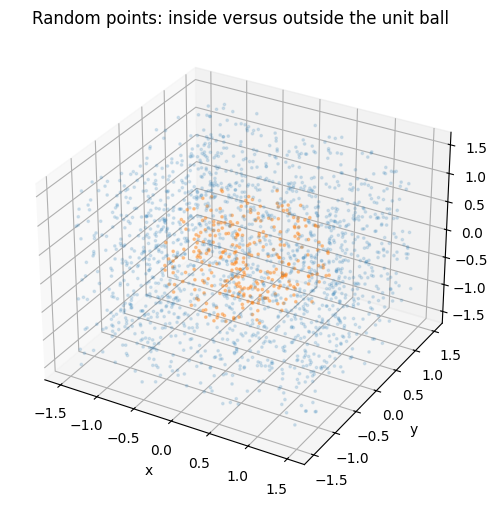

Number inside or on the ball: 297
Number outside the ball: 1703


In [22]:
def inside_closed_ball(points, center=(0, 0, 0), radius=1):
    """Return a Boolean array indicating whether each point is inside or on a ball."""
    points = np.asarray(points, dtype=float)
    center = np.asarray(center, dtype=float)
    return np.sum((points - center)**2, axis=1) <= radius**2

rng = np.random.default_rng(2321)
points = rng.uniform(-1.5, 1.5, size=(2000, 3))
mask = inside_closed_ball(points, center=(0, 0, 0), radius=1)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points[~mask, 0], points[~mask, 1], points[~mask, 2], s=3, alpha=0.15)
ax.scatter(points[mask, 0], points[mask, 1], points[mask, 2], s=3, alpha=0.35)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Random points: inside versus outside the unit ball")
plt.show()

print("Number inside or on the ball:", mask.sum())
print("Number outside the ball:", (~mask).sum())

### Task 6.1

Describe the region

$$
x^2+y^2+z^2>2z.
$$

Complete the square by hand, then verify the interpretation below.

Boundary sphere center: [0 0 1]
Boundary sphere radius: 1
Region: points outside the sphere; boundary not included.


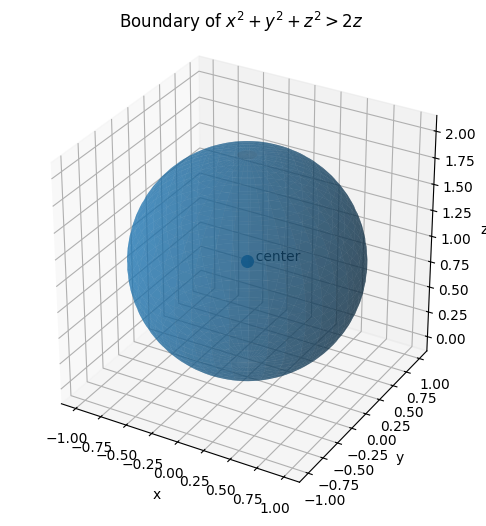

In [23]:
# Student workspace for Task 6.1
# x^2 + y^2 + z^2 > 2z
# x^2 + y^2 + (z - 1)^2 > 1

center = np.array([0, 0, 1])
radius = 1

print("Boundary sphere center:", center)
print("Boundary sphere radius:", radius)
print("Region: points outside the sphere; boundary not included.")

X, Y, Z = sphere_points(center=center, radius=radius)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0)
ax.scatter([center[0]], [center[1]], [center[2]], s=70)
ax.text(center[0], center[1], center[2], "  center")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1, 1, 1])
ax.set_title(r"Boundary of $x^2+y^2+z^2>2z$")
plt.show()

**Reference solution.**

$$
\begin{aligned}
x^2+y^2+z^2&>2z,\\
x^2+y^2+z^2-2z&>0,\\
x^2+y^2+(z-1)^2&>1.
\end{aligned}
$$

So the region consists of points whose distance from $(0,0,1)$ is greater than $1$.  It is the outside of the sphere of radius $1$ centered at $(0,0,1)$, not including the boundary.

### Task 6.2: Complete the square

Complete the square and describe the region

$$
x^2+y^2+z^2-4x+6y-2z\le 10.
$$

In [24]:
# Student workspace for Task 6.2
# Complete squares:
# x^2 - 4x = (x - 2)^2 - 4
# y^2 + 6y = (y + 3)^2 - 9
# z^2 - 2z = (z - 1)^2 - 1
# Therefore (x-2)^2 + (y+3)^2 + (z-1)^2 <= 24

center = np.array([2, -3, 1])
radius_squared = 24
radius = np.sqrt(radius_squared)

print("center =", center)
print("radius^2 =", radius_squared)
print("radius =", radius)
print("Region: closed ball centered at (2,-3,1) with radius sqrt(24).")

center = [ 2 -3  1]
radius^2 = 24
radius = 4.898979485566356
Region: closed ball centered at (2,-3,1) with radius sqrt(24).


**Reference solution.**

$$
\begin{aligned}
x^2+y^2+z^2-4x+6y-2z&\le 10,\\
(x-2)^2-4+(y+3)^2-9+(z-1)^2-1&\le 10,\\
(x-2)^2+(y+3)^2+(z-1)^2&\le 24.
\end{aligned}
$$

This is the closed ball centered at $(2,-3,1)$ with radius $\sqrt{24}=2\sqrt 6$.

In [25]:
assert np.allclose(center, [2, -3, 1])
assert np.allclose(radius_squared, 24)
print("Task 6.2 check passed.")

Task 6.2 check passed.


## 7. Lines, planes, and hyperplanes as flat sets

A hyperplane in $\mathbb R^n$ has the form

$$
w_1x_1+w_2x_2+\cdots+w_nx_n=b.
$$

In $\mathbb R^2$, this is a line.  In $\mathbb R^3$, this is a plane.  In higher-dimensional data science, it is a linear decision boundary.

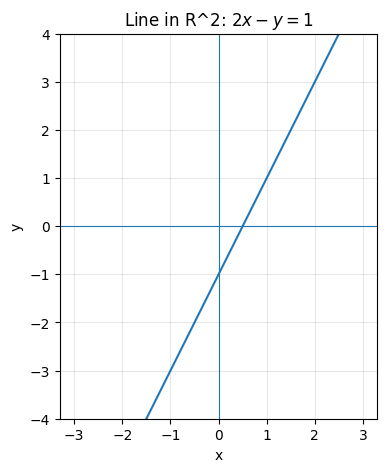

In [26]:
# A line in R^2: 2x - y = 1, so y = 2x - 1.
x = np.linspace(-3, 3, 300)
y = 2*x - 1

plt.figure(figsize=(6, 5))
plt.plot(x, y)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Line in R^2: $2x-y=1$")
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.ylim(-4, 4)
plt.show()

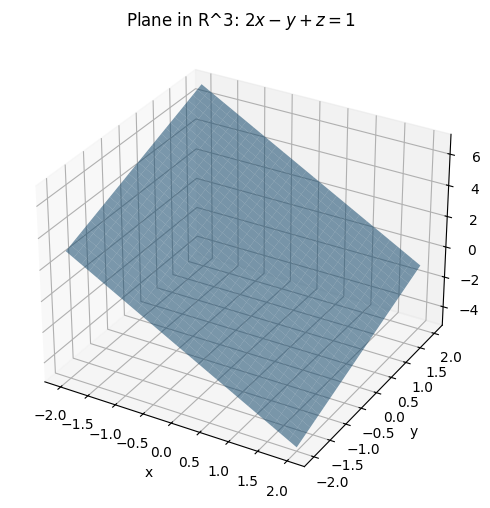

In [27]:
# A plane in R^3: 2x - y + z = 1, so z = 1 - 2x + y.
x = np.linspace(-2, 2, 30)
y = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x, y)
Z = 1 - 2*X + Y

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.55, linewidth=0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"Plane in R^3: $2x-y+z=1$")
plt.show()

### Task 7.1

A simple classifier in $\mathbb R^2$ predicts class $+1$ when

$$
w\cdot x-b>0,
$$

where $w=(2,-1)$ and $b=1$.  Plot the decision boundary and shade the two sides using the sign of $w\cdot x-b$.

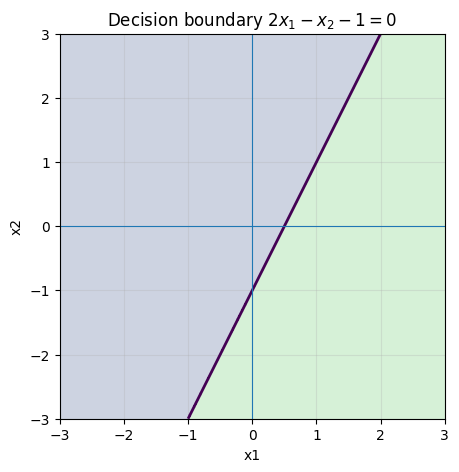

In [28]:
# Student workspace for Task 7.1
w = np.array([2, -1])
b = 1

x1 = np.linspace(-3, 3, 250)
x2 = np.linspace(-3, 3, 250)
X1, X2 = np.meshgrid(x1, x2)
Score = w[0]*X1 + w[1]*X2 - b

plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, Score > 0, levels=[-0.5, 0.5, 1.5], alpha=0.25)
plt.contour(X1, X2, Score, levels=[0], linewidths=2)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(r"Decision boundary $2x_1-x_2-1=0$")
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

**Reference solution.**  The boundary is $2x_1-x_2-1=0$, or $x_2=2x_1-1$.  One side has positive score and the other side has negative score.

## 8. Collinearity by distances and displacement vectors

Three points are collinear if they lie on one straight line.  In computation, a clean way to test this is to check whether two displacement vectors are scalar multiples.

For example, for $A$, $B$, and $C$, compare

$$
\overrightarrow{AB}=B-A, \qquad \overrightarrow{AC}=C-A.
$$

In $\mathbb R^3$, you can also use the cross product: $A$, $B$, $C$ are collinear if $(B-A)\times(C-A)=0$.

In [29]:
def are_collinear_3d(A, B, C, tol=1e-10):
    """Check collinearity of three points in R^3 using the cross product."""
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    C = np.asarray(C, dtype=float)
    return np.linalg.norm(np.cross(B - A, C - A)) < tol

A = np.array([2, 4, 2])
B = np.array([3, 7, -2])
C = np.array([1, 3, 3])

print("AB =", B - A)
print("AC =", C - A)
print("AB x AC =", np.cross(B - A, C - A))
print("Are the points collinear?", are_collinear_3d(A, B, C))

print("Distances:")
print("|AB| =", distance(A, B))
print("|AC| =", distance(A, C))
print("|BC| =", distance(B, C))

AB = [ 1  3 -4]
AC = [-1 -1  1]
AB x AC = [-1  3  2]
Are the points collinear? False
Distances:
|AB| = 5.0990195135927845
|AC| = 1.7320508075688772
|BC| = 6.708203932499369


### Task 8.1

Determine whether the points

$$
(0,0,0), \qquad (1,2,3), \qquad (2,4,6)
$$

lie on one line.

In [30]:
# Student workspace for Task 8.1
A = np.array([0, 0, 0])
B = np.array([1, 2, 3])
C = np.array([2, 4, 6])

AB = B - A
AC = C - A
collinear = are_collinear_3d(A, B, C)

print("AB =", AB)
print("AC =", AC)
print("Are they collinear?", collinear)

AB = [1 2 3]
AC = [2 4 6]
Are they collinear? True


**Reference solution.**

$$
\overrightarrow{AB}=(1,2,3), \qquad \overrightarrow{AC}=(2,4,6)=2(1,2,3).
$$

The displacement vectors are scalar multiples, so the points are collinear.

In [31]:
assert collinear
print("Task 8.1 check passed.")

Task 8.1 check passed.


## 9. Nearest-neighbor search and data geometry

A data set with $m$ observations and $n$ features can be stored as an $m\times n$ matrix.  Each row is a point in $\mathbb R^n$.

Given a query point $q$, the nearest neighbor is the data point with smallest Euclidean distance to $q$.

Index of nearest point: 5
Nearest point: [0.4898 0.3569]
Distance: 0.2812596511504091


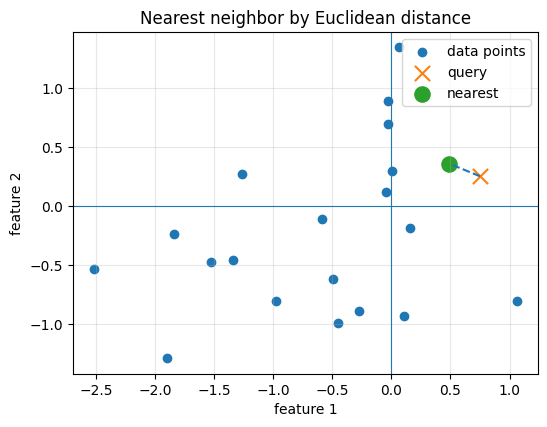

In [32]:
rng = np.random.default_rng(7)
X = rng.normal(size=(20, 2))
query = np.array([0.75, 0.25])

dists = np.linalg.norm(X - query, axis=1)
idx = np.argmin(dists)
nearest = X[idx]

print("Index of nearest point:", idx)
print("Nearest point:", nearest)
print("Distance:", dists[idx])

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], label="data points")
plt.scatter([query[0]], [query[1]], marker="x", s=120, label="query")
plt.scatter([nearest[0]], [nearest[1]], s=120, label="nearest")
plt.plot([query[0], nearest[0]], [query[1], nearest[1]], linestyle="--")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Nearest neighbor by Euclidean distance")
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.show()

### Task 9.1

Create a new query point and find its nearest neighbor in the same data set.

query2 = [-0.5  1. ]
nearest index = 18
nearest point = [-0.0325  0.8844]
nearest distance = 0.48156168775217467


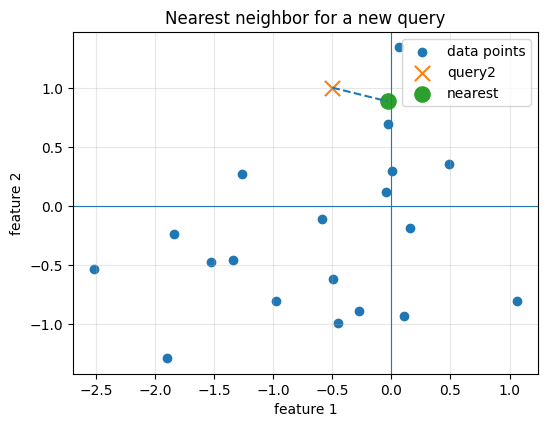

In [33]:
# Student workspace for Task 9.1
query2 = np.array([-0.5, 1.0])

dists2 = np.linalg.norm(X - query2, axis=1)
idx2 = np.argmin(dists2)
nearest2 = X[idx2]

print("query2 =", query2)
print("nearest index =", idx2)
print("nearest point =", nearest2)
print("nearest distance =", dists2[idx2])

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], label="data points")
plt.scatter([query2[0]], [query2[1]], marker="x", s=120, label="query2")
plt.scatter([nearest2[0]], [nearest2[1]], s=120, label="nearest")
plt.plot([query2[0], nearest2[0]], [query2[1], nearest2[1]], linestyle="--")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Nearest neighbor for a new query")
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.show()

In [34]:
assert idx2 == int(np.argmin(np.linalg.norm(X - query2, axis=1)))
print("Task 9.1 check passed.")

Task 9.1 check passed.


## 10. Why scaling matters

Euclidean distance depends on units.  If one feature has much larger numerical scale than another, it can dominate the distance.

This is why data analysis and machine learning often standardize features before using Euclidean distance.

In [35]:
# Two patients represented by height in cm and cholesterol in mg/dL.
patient_A = np.array([170, 180])
patient_B = np.array([175, 210])
patient_C = np.array([185, 185])

print("Raw distances from A:")
print("dist(A,B) =", distance(patient_A, patient_B))
print("dist(A,C) =", distance(patient_A, patient_C))

patients = np.vstack([patient_A, patient_B, patient_C])
means = patients.mean(axis=0)
stds = patients.std(axis=0, ddof=0)
patients_standardized = (patients - means) / stds

A_s, B_s, C_s = patients_standardized

print("\nStandardized data:")
print(patients_standardized)
print("\nStandardized distances from A:")
print("dist(A,B) =", distance(A_s, B_s))
print("dist(A,C) =", distance(A_s, C_s))

Raw distances from A:
dist(A,B) = 30.4138126514911
dist(A,C) = 15.811388300841896

Standardized data:
[[-1.069  -0.889 ]
 [-0.2673  1.397 ]
 [ 1.3363 -0.508 ]]

Standardized distances from A:
dist(A,B) = 2.4225324754211335
dist(A,C) = 2.4353389037332906


### Task 10.1

Explain in one or two sentences why the nearest neighbor can change after standardization.

**Your answer:**

Standardization changes each coordinate to a comparable unit, usually measured in standard deviations.  Therefore a feature with large raw units no longer automatically dominates the distance.

## 11. Distances in high dimension

Euclidean geometry works in every dimension, but high-dimensional spaces can feel surprising.  One important phenomenon is distance concentration: distances between random points may become relatively similar as dimension grows.

The next simulation samples pairs of points from the unit cube $[0,1]^n$ and records their Euclidean distances.

dimension | mean distance | std distance | std/mean
        2 |        0.5237 |       0.2507 |   0.4788
        5 |        0.8695 |       0.2447 |   0.2815
       10 |        1.2684 |       0.2490 |   0.1963
       25 |        2.0284 |       0.2416 |   0.1191
       50 |        2.8793 |       0.2441 |   0.0848
      100 |        4.0780 |       0.2399 |   0.0588
      250 |        6.4564 |       0.2386 |   0.0370


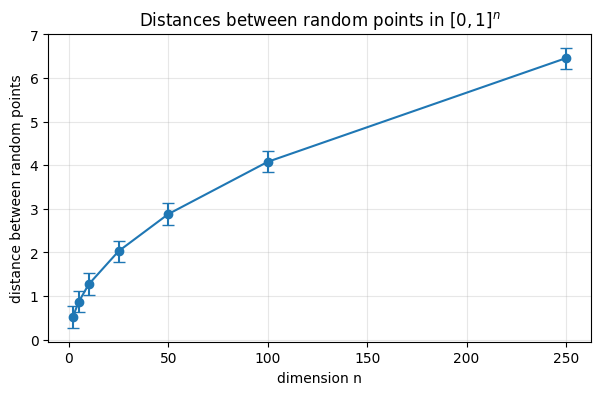

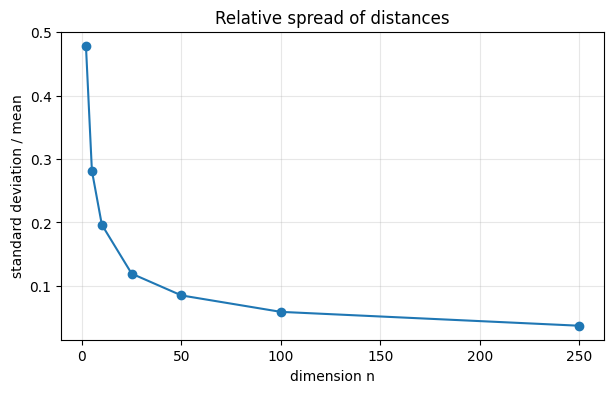

In [36]:
rng = np.random.default_rng(2321)
dimensions = [2, 5, 10, 25, 50, 100, 250]
means = []
stds = []
coefficients_of_variation = []

for n in dimensions:
    A = rng.random((3000, n))
    B = rng.random((3000, n))
    d = np.linalg.norm(A - B, axis=1)
    means.append(d.mean())
    stds.append(d.std())
    coefficients_of_variation.append(d.std() / d.mean())

print("dimension | mean distance | std distance | std/mean")
for n, m, s, cv in zip(dimensions, means, stds, coefficients_of_variation):
    print(f"{n:9d} | {m:13.4f} | {s:12.4f} | {cv:8.4f}")

plt.figure(figsize=(7, 4))
plt.errorbar(dimensions, means, yerr=stds, marker="o", capsize=4)
plt.xlabel("dimension n")
plt.ylabel("distance between random points")
plt.title(r"Distances between random points in $[0,1]^n$")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(dimensions, coefficients_of_variation, marker="o")
plt.xlabel("dimension n")
plt.ylabel("standard deviation / mean")
plt.title("Relative spread of distances")
plt.grid(True, alpha=0.3)
plt.show()

### Task 11.1

What happens to the mean distance as the dimension increases?  What happens to the relative spread, measured by standard deviation divided by mean?

**Your answer:**

The mean distance increases with dimension.  The relative spread tends to decrease, so many distances become similar relative to their size.

## 12. Pairwise distance matrix

For data analysis, it is often useful to compute all pairwise distances between observations.

Given data points $x_1,\ldots,x_m\in\mathbb R^n$, the pairwise distance matrix $D$ has entries

$$
D_{ij}=d(x_i,x_j).
$$

In [37]:
def pairwise_distances(X):
    """Return the pairwise Euclidean distance matrix for rows of X."""
    X = np.asarray(X, dtype=float)
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt(np.sum(diff**2, axis=2))

X_small = np.array([
    [0, 0],
    [1, 0],
    [0, 2],
    [2, 2]
], dtype=float)

D = pairwise_distances(X_small)
print(D)

[[0.     1.     2.     2.8284]
 [1.     0.     2.2361 2.2361]
 [2.     2.2361 0.     2.    ]
 [2.8284 2.2361 2.     0.    ]]


### Task 12.1

Use the pairwise distance matrix to find the two closest distinct points in `X_small`.

In [38]:
# Student workspace for Task 12.1
D_no_diagonal = D.copy()
np.fill_diagonal(D_no_diagonal, np.inf)
closest_pair = np.unravel_index(np.argmin(D_no_diagonal), D_no_diagonal.shape)
closest_distance = D_no_diagonal[closest_pair]

print("closest pair of indices =", closest_pair)
print("point 1 =", X_small[closest_pair[0]])
print("point 2 =", X_small[closest_pair[1]])
print("distance =", closest_distance)

closest pair of indices = (np.int64(0), np.int64(1))
point 1 = [0. 0.]
point 2 = [1. 0.]
distance = 1.0


**Reference solution.**  The closest distance is $1$, between the points $(0,0)$ and $(1,0)$.  Depending on tie-breaking, the pair may appear as `(0, 1)` or `(1, 0)`.

In [39]:
assert np.allclose(closest_distance, 1)
print("Task 12.1 check passed.")

Task 12.1 check passed.


## 13. Mini-project: nearest neighbors before and after standardization

This project connects Chapter 2 geometry to data analysis.

You will simulate data with two features on very different scales, compute nearest neighbors, then standardize the data and recompute nearest neighbors.

Raw nearest index: 1
Raw nearest point: [  -0.3678 1005.61  ]
Raw distance: 5.676699689703102

Standardized nearest index: 28
Standardized nearest point: [   0.3926 1025.6686]
Standardized distance: 0.19607382005785065


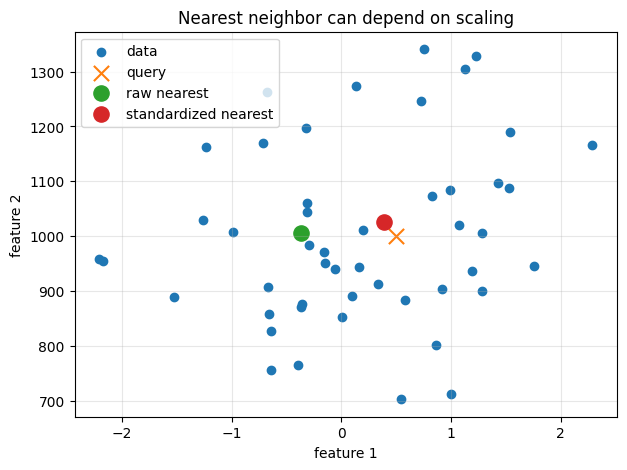

In [40]:
# Mini-project setup
rng = np.random.default_rng(123)

# Feature 1 has small scale; feature 2 has large scale.
feature1 = rng.normal(loc=0, scale=1, size=50)
feature2 = rng.normal(loc=1000, scale=200, size=50)
X_project = np.column_stack([feature1, feature2])
query_project = np.array([0.5, 1000])

# Raw nearest neighbor
raw_dists = np.linalg.norm(X_project - query_project, axis=1)
raw_idx = np.argmin(raw_dists)

# Standardized nearest neighbor
mean = X_project.mean(axis=0)
std = X_project.std(axis=0)
X_project_s = (X_project - mean) / std
query_project_s = (query_project - mean) / std
std_dists = np.linalg.norm(X_project_s - query_project_s, axis=1)
std_idx = np.argmin(std_dists)

print("Raw nearest index:", raw_idx)
print("Raw nearest point:", X_project[raw_idx])
print("Raw distance:", raw_dists[raw_idx])
print()
print("Standardized nearest index:", std_idx)
print("Standardized nearest point:", X_project[std_idx])
print("Standardized distance:", std_dists[std_idx])

plt.figure(figsize=(7, 5))
plt.scatter(X_project[:, 0], X_project[:, 1], label="data")
plt.scatter([query_project[0]], [query_project[1]], marker="x", s=120, label="query")
plt.scatter([X_project[raw_idx, 0]], [X_project[raw_idx, 1]], s=120, label="raw nearest")
plt.scatter([X_project[std_idx, 0]], [X_project[std_idx, 1]], s=120, label="standardized nearest")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Nearest neighbor can depend on scaling")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Mini-project questions

1. Did the nearest neighbor change after standardization?
2. Which feature dominates the raw distance?
3. Why is standardization often important before using Euclidean distance?
4. Change the query point and rerun the cell.  Does the same phenomenon occur?

## 14. Additional challenge exercises

Use Python where helpful, but also write mathematical explanations.

1. Find all points on the $z$-axis that are distance $5$ from $(3,4,0)$.
2. Find the intersection of the sphere $x^2+y^2+z^2=25$ with the plane $z=4$.
3. Show computationally that the set of points equidistant from $A=(1,0,0)$ and $B=(-1,0,0)$ lies on the plane $x=0$.
4. Generate 1000 random points in $\mathbb R^{10}$.  Compute the pairwise distance from the first point to all others.  What is the nearest point?  What is the farthest point?
5. Repeat the previous experiment in dimensions $2, 10, 100$.  How does the ratio of nearest distance to farthest distance change?

In [41]:
# Workspace for challenge exercise 1
# Points on the z-axis have the form (0,0,z).
# Distance to (3,4,0) is sqrt(3^2 + 4^2 + z^2) = sqrt(25 + z^2).
# Set sqrt(25 + z^2) = 5, so z = 0.

z_values = [0]
points_on_z_axis = [np.array([0, 0, z]) for z in z_values]
print(points_on_z_axis)

[array([0, 0, 0])]


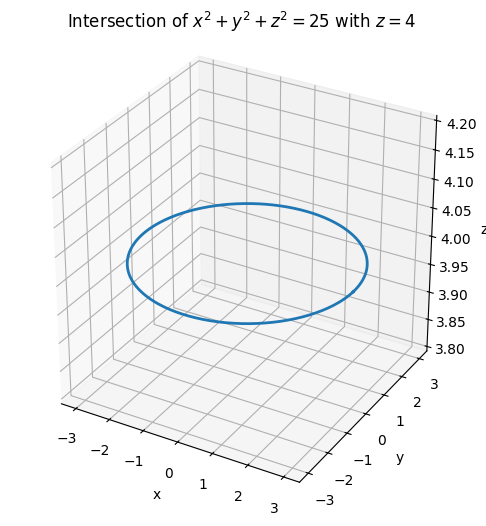

In [42]:
# Workspace for challenge exercise 2
# If z=4, then x^2 + y^2 + 16 = 25, so x^2 + y^2 = 9.
# The intersection is a circle of radius 3 in the plane z=4.

theta = np.linspace(0, 2*np.pi, 300)
X = 3*np.cos(theta)
Y = 3*np.sin(theta)
Z = 4*np.ones_like(theta)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(X, Y, Z, linewidth=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1, 1, 1])
ax.set_title(r"Intersection of $x^2+y^2+z^2=25$ with $z=4$")
plt.show()

## 15. Lab summary

In this lab you practiced the computational geometry of Euclidean space:

- arrays represent points and vectors in $\mathbb R^n$;
- subtraction gives displacement;
- the Euclidean norm gives length;
- distance is the norm of displacement;
- coordinate-plane projections are obtained by setting one coordinate to zero;
- equations describe different objects in different ambient spaces;
- spheres and balls are sets defined by distance from a center;
- inequalities describe regions;
- nearest-neighbor search uses Euclidean distance;
- high-dimensional distances can behave differently from low-dimensional intuition.

These ideas will support limits, continuity, tangent planes, gradients, multiple integrals, optimization, and data geometry throughout multivariable calculus.